# Importing libraries

In [348]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Loading the data set

In [349]:
df = pd.read_csv('data.csv')

In [350]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


# Data visualization

In [351]:
#sns.pairplot(df)

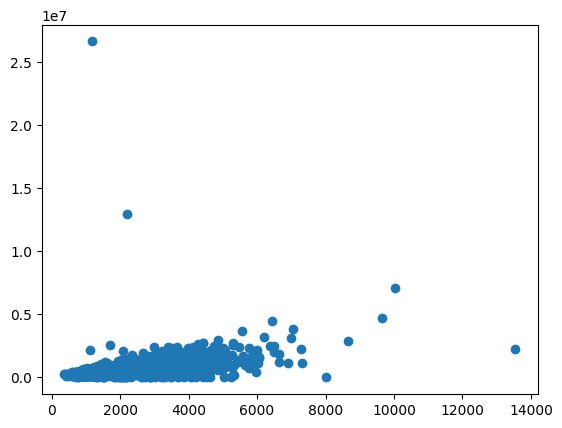

In [352]:
plt.scatter(df['sqft_living'],df['price'])

<Axes: xlabel='view', ylabel='price'>

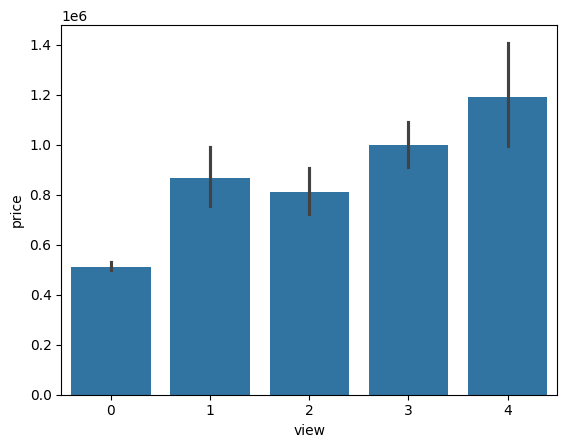

In [353]:
sns.barplot(x=df['view'],y=df['price'])

<Axes: xlabel='price', ylabel='city'>

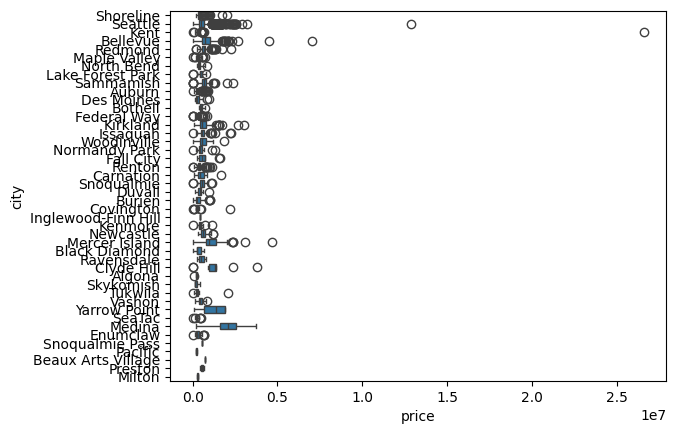

In [354]:
sns.boxplot(x=df['price'],y=df['city'])

# Data cleaning and preprocessing

In [355]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [356]:
df['price'].describe()

count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64

In [357]:
df['city'].value_counts()

city
Seattle                1573
Renton                  293
Bellevue                286
Redmond                 235
Kirkland                187
Issaquah                187
Kent                    185
Auburn                  176
Sammamish               175
Federal Way             148
Shoreline               123
Woodinville             115
Maple Valley             96
Mercer Island            86
Burien                   74
Snoqualmie               71
Kenmore                  66
Des Moines               58
North Bend               50
Covington                43
Duvall                   42
Lake Forest Park         36
Bothell                  33
Newcastle                33
Tukwila                  29
SeaTac                   29
Vashon                   29
Enumclaw                 28
Carnation                22
Normandy Park            18
Clyde Hill               11
Fall City                11
Medina                   11
Black Diamond             9
Ravensdale                7
Pacific        

In [358]:
df['country'].value_counts()

country
USA    4600
Name: count, dtype: int64

In [359]:
df= df.drop('country',axis =1)

In [360]:
df['date'].value_counts()

date
2014-06-23 00:00:00    142
2014-06-25 00:00:00    131
2014-06-26 00:00:00    131
2014-07-08 00:00:00    127
2014-07-09 00:00:00    121
                      ... 
2014-06-07 00:00:00      4
2014-07-06 00:00:00      3
2014-05-11 00:00:00      2
2014-07-04 00:00:00      2
2014-05-17 00:00:00      1
Name: count, Length: 70, dtype: int64

In [361]:
df= df.drop('date',axis =1)

In [362]:
df.isnull().sum()

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
dtype: int64

In [363]:
df['floors'].value_counts()

floors
1.0    2174
2.0    1811
1.5     444
3.0     128
2.5      41
3.5       2
Name: count, dtype: int64

In [364]:
df['waterfront'].value_counts()

waterfront
0    4567
1      33
Name: count, dtype: int64

In [365]:
yrs_built = []

for i in df['yr_built']:
    built_yrs = 2026 - i
    yrs_built.append(built_yrs)

In [366]:
df['yr_built'] = yrs_built

In [367]:
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip
0,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,71,2005,18810 Densmore Ave N,Shoreline,WA 98133
1,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,105,0,709 W Blaine St,Seattle,WA 98119
2,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,60,0,26206-26214 143rd Ave SE,Kent,WA 98042
3,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,63,0,857 170th Pl NE,Bellevue,WA 98008
4,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,50,1992,9105 170th Ave NE,Redmond,WA 98052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,72,1979,501 N 143rd St,Seattle,WA 98133
4596,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,43,2009,14855 SE 10th Pl,Bellevue,WA 98007
4597,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,17,0,759 Ilwaco Pl NE,Renton,WA 98059
4598,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,52,0,5148 S Creston St,Seattle,WA 98178


In [368]:
reno_yr = []

for i in df['yr_renovated']:
    if i == 0 :
        reno_yrs = 0
    else:
        reno_yrs = 2026 - i
    reno_yr.append(reno_yrs)

In [369]:
df['yr_renovated'] = reno_yr


In [370]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,71,21,18810 Densmore Ave N,Shoreline,WA 98133
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,105,0,709 W Blaine St,Seattle,WA 98119
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,60,0,26206-26214 143rd Ave SE,Kent,WA 98042
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,63,0,857 170th Pl NE,Bellevue,WA 98008
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,50,34,9105 170th Ave NE,Redmond,WA 98052


In [371]:
df['street'].value_counts()

street
2520 Mulberry Walk NE    4
2500 Mulberry Walk NE    3
11716 16th Ave NE        2
35229 SE Terrace St      2
13800 453rd Ave SE       2
                        ..
501 N 143rd St           1
14855 SE 10th Pl         1
759 Ilwaco Pl NE         1
5148 S Creston St        1
8519 28th Ave NW         1
Name: count, Length: 4525, dtype: int64

In [372]:
df = df.drop('street',axis=1)

In [373]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'city', 'statezip'],
      dtype='object')

In [374]:
df = df.drop('statezip',axis=1)

In [375]:
df = pd.get_dummies(data=df,columns=['city'],drop_first=True)

In [376]:
df = df.astype(int)
df_scaled = df_scaled.astype(int)

In [377]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'city_Auburn', 'city_Beaux Arts Village',
       'city_Bellevue', 'city_Black Diamond', 'city_Bothell', 'city_Burien',
       'city_Carnation', 'city_Clyde Hill', 'city_Covington',
       'city_Des Moines', 'city_Duvall', 'city_Enumclaw', 'city_Fall City',
       'city_Federal Way', 'city_Inglewood-Finn Hill', 'city_Issaquah',
       'city_Kenmore', 'city_Kent', 'city_Kirkland', 'city_Lake Forest Park',
       'city_Maple Valley', 'city_Medina', 'city_Mercer Island', 'city_Milton',
       'city_Newcastle', 'city_Normandy Park', 'city_North Bend',
       'city_Pacific', 'city_Preston', 'city_Ravensdale', 'city_Redmond',
       'city_Renton', 'city_Sammamish', 'city_SeaTac', 'city_Seattle',
       'city_Shoreline', 'city_Skykomish', 'city_Snoqualmie',
       'city_Snoqualmie Pass', 'city_Tukwila', 'city_V

In [378]:
df['price_category'] = pd.qcut(
    df['price'],
    q=4,
    labels=False
)


In [379]:
scaler = StandardScaler()

In [380]:
df_scaled = df.copy()

In [381]:
cols = ['sqft_living','sqft_lot','yr_built','yr_renovated','sqft_above','sqft_basement','price']
df[cols] = scaler.fit_transform(df[cols])

In [382]:
cols = ['sqft_living','sqft_lot','yr_built','yr_renovated','bedrooms','bathrooms','condition','floors','sqft_above','sqft_basement','price']
df_scaled[cols] = scaler.fit_transform(df_scaled[cols])

In [383]:
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,city_Seattle,city_Shoreline,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point,price_category
0,-0.423864,3,1,-0.829971,-0.193434,1,0,0,3,-0.565224,...,0,1,0,0,0,0,0,0,0,0
1,3.249598,5,2,1.568528,-0.161718,2,0,4,5,1.789559,...,1,0,0,0,0,0,0,0,0,3
2,-0.372424,3,2,-0.217367,-0.080978,1,0,0,4,0.119171,...,0,0,0,0,0,0,0,0,0,1
3,-0.234071,3,2,-0.144686,-0.190145,1,0,0,4,-0.959621,...,0,0,0,0,0,0,0,0,0,1
4,-0.003482,4,2,-0.206984,-0.121306,1,0,0,4,-0.797222,...,0,0,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,-0.432438,3,1,-0.653458,-0.236689,1,0,0,4,-0.368025,...,1,0,0,0,0,0,0,0,0,0
4596,-0.031271,3,2,-0.705374,-0.202882,2,0,0,3,-0.426025,...,0,0,0,0,0,0,0,0,0,2
4597,-0.239563,3,2,0.904009,-0.218462,2,0,0,3,1.371962,...,0,0,0,0,0,0,0,0,0,1
4598,-0.618268,4,2,-0.051238,-0.229164,1,0,0,3,-0.878421,...,1,0,0,0,0,0,0,0,0,0


In [384]:
df_scaled

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,city_Seattle,city_Shoreline,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point,price_category
0,-0.423864,-0.441122,-1.048942,-0.829971,-0.193434,-0.831557,0,0,-0.667112,-0.565224,...,0,1,0,0,0,0,0,0,0,0
1,3.249598,1.759705,0.280662,1.568528,-0.161718,0.979599,0,4,2.286416,1.789559,...,1,0,0,0,0,0,0,0,0,3
2,-0.372424,-0.441122,0.280662,-0.217367,-0.080978,-0.831557,0,0,0.809652,0.119171,...,0,0,0,0,0,0,0,0,0,1
3,-0.234071,-0.441122,0.280662,-0.144686,-0.190145,-0.831557,0,0,0.809652,-0.959621,...,0,0,0,0,0,0,0,0,0,1
4,-0.003482,0.659291,0.280662,-0.206984,-0.121306,-0.831557,0,0,0.809652,-0.797222,...,0,0,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,-0.432438,-0.441122,-1.048942,-0.653458,-0.236689,-0.831557,0,0,0.809652,-0.368025,...,1,0,0,0,0,0,0,0,0,0
4596,-0.031271,-0.441122,0.280662,-0.705374,-0.202882,0.979599,0,0,-0.667112,-0.426025,...,0,0,0,0,0,0,0,0,0,2
4597,-0.239563,-0.441122,0.280662,0.904009,-0.218462,0.979599,0,0,-0.667112,1.371962,...,0,0,0,0,0,0,0,0,0,1
4598,-0.618268,0.659291,0.280662,-0.051238,-0.229164,-0.831557,0,0,-0.667112,-0.878421,...,1,0,0,0,0,0,0,0,0,0


In [385]:
cat_features = ['city_Auburn', 'city_Beaux Arts Village',
       'city_Bellevue', 'city_Black Diamond', 'city_Bothell', 'city_Burien',
       'city_Carnation', 'city_Clyde Hill', 'city_Covington',
       'city_Des Moines', 'city_Duvall', 'city_Enumclaw', 'city_Fall City',
       'city_Federal Way', 'city_Inglewood-Finn Hill', 'city_Issaquah',
       'city_Kenmore', 'city_Kent', 'city_Kirkland', 'city_Lake Forest Park',
       'city_Maple Valley', 'city_Medina', 'city_Mercer Island', 'city_Milton',
       'city_Newcastle', 'city_Normandy Park', 'city_North Bend',
       'city_Pacific', 'city_Preston', 'city_Ravensdale', 'city_Redmond',
       'city_Renton', 'city_Sammamish', 'city_SeaTac', 'city_Seattle',
       'city_Shoreline', 'city_Skykomish', 'city_Snoqualmie',
       'city_Snoqualmie Pass', 'city_Tukwila', 'city_Vashon',
       'city_Woodinville', 'city_Yarrow Point','waterfront']

In [386]:
from scipy.stats import chi2_contingency

alpha = 0.05
chi2_results = {}


for col in cat_features:
    contingency = pd.crosstab(
        df[col],
        df['price_category']
    )
    
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    
    decision = (
        'Reject Null (Keep Feature)'
        if p_val < alpha
        else 'Accept Null (Drop Feature)'
    )

    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

pd.DataFrame(chi2_results).T

,chi2_statistic,p_value,Decision
city_Auburn,202.143268,0.0,Reject Null (Keep Feature)
city_Beaux Arts Village,3.000652,0.391525,Accept Null (Drop Feature)
city_Bellevue,220.879816,0.0,Reject Null (Keep Feature)
city_Black Diamond,6.568407,0.087003,Accept Null (Drop Feature)
city_Bothell,28.904327,0.000002,Reject Null (Keep Feature)
city_Burien,43.785456,0.0,Reject Null (Keep Feature)
city_Carnation,2.009611,0.570414,Accept Null (Drop Feature)
city_Clyde Hill,19.956814,0.000173,Reject Null (Keep Feature)
city_Covington,86.834974,0.0,Reject Null (Keep Feature)
city_Des Moines,72.151111,0.0,Reject Null (Keep Feature)


In [387]:
keep_features = [
    'city_Auburn',
    'city_Bellevue',
    'city_Bothell',
    'city_Burien',
    'city_Clyde Hill',
    'city_Covington',
    'city_Des Moines',
    'city_Duvall',
    'city_Enumclaw',
    'city_Federal Way',
    'city_Issaquah',
    'city_Kenmore',
    'city_Kent',
    'city_Kirkland',
    'city_Lake Forest Park',
    'city_Maple Valley',
    'city_Medina',
    'city_Mercer Island',
    'city_Newcastle',
    'city_North Bend',
    'city_Pacific',
    'city_Redmond',
    'city_Renton',
    'city_Sammamish',
    'city_SeaTac',
    'city_Seattle',
    'city_Shoreline',
    'city_Snoqualmie',
    'city_Tukwila',
    'city_Woodinville',
    'city_Yarrow Point',
    'waterfront','bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'floors',
    'view',
    'condition',
    'sqft_above',
    'sqft_basement','price'
]

In [388]:
numeric_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built']
df[numeric_cols].corr()['price']

price            1.000000
bedrooms         0.200336
bathrooms        0.317229
sqft_living      0.430410
sqft_lot         0.050451
floors           0.137125
view             0.228504
condition        0.034915
sqft_above       0.367570
sqft_basement    0.210427
yr_built        -0.021857
Name: price, dtype: float64

In [389]:

keep_features

['city_Auburn',
 'city_Bellevue',
 'city_Bothell',
 'city_Burien',
 'city_Clyde Hill',
 'city_Covington',
 'city_Des Moines',
 'city_Duvall',
 'city_Enumclaw',
 'city_Federal Way',
 'city_Issaquah',
 'city_Kenmore',
 'city_Kent',
 'city_Kirkland',
 'city_Lake Forest Park',
 'city_Maple Valley',
 'city_Medina',
 'city_Mercer Island',
 'city_Newcastle',
 'city_North Bend',
 'city_Pacific',
 'city_Redmond',
 'city_Renton',
 'city_Sammamish',
 'city_SeaTac',
 'city_Seattle',
 'city_Shoreline',
 'city_Snoqualmie',
 'city_Tukwila',
 'city_Woodinville',
 'city_Yarrow Point',
 'waterfront',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'view',
 'condition',
 'sqft_above',
 'sqft_basement',
 'price']

In [390]:
df_final = df[keep_features]
df_final_scaled =df_scaled[keep_features]

# Model 1 

In [391]:
X = df_final.drop('price',axis=1)
y = df_final['price']

In [431]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33,random_state=23)

In [432]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [433]:
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.6317548334493579
MAE: 0.2347714172750768
RMSE: 0.4027243572395106


# Model 2

In [434]:
X = df_final_scaled.drop('price',axis=1)
y = df_final_scaled['price']

In [435]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33,random_state=23)

In [436]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [437]:
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.6317548334493579
MAE: 0.23477141727507703
RMSE: 0.40272435723951056
